In [34]:
import pandas as pd
import numpy as np
import os
import webbrowser

# visualisation
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# mesa
from mesa import Agent, Model
from mesa.time import BaseScheduler

In [35]:
df = pd.read_csv( r"C:\Users\Dev Sharma\OneDrive\Documents\MDP\Datasets\Combined_Aircraft_Tracking.csv")

print("Rows loaded:", len(df))
df

Rows loaded: 2120


,Timestamp,UTC,Callsign,Position,Altitude,Speed,Direction,source_file
0,1770575290,2026-02-08T18:28:10Z,NKS2061,"28.434471,-81.315475",0,3,154,NK2061_3e3f8403.csv
1,1770575501,2026-02-08T18:31:41Z,NKS2061,"28.434677,-81.31665",0,0,22,NK2061_3e3f8403.csv
2,1770575611,2026-02-08T18:33:31Z,NKS2061,"28.435101,-81.317001",0,0,295,NK2061_3e3f8403.csv
3,1770575617,2026-02-08T18:33:37Z,NKS2061,"28.435101,-81.317253",0,8,272,NK2061_3e3f8403.csv
4,1770575622,2026-02-08T18:33:42Z,NKS2061,"28.43508,-81.317482",0,9,264,NK2061_3e3f8403.csv
...,...,...,...,...,...,...,...,...
2115,1769977275,2026-02-01T20:21:15Z,SWA3012,"39.175709,-76.670181",0,7,309,WN3012_3e25d69e.csv
2116,1769977287,2026-02-01T20:21:27Z,SWA3012,"39.17593,-76.670158",0,4,30,WN3012_3e25d69e.csv
2117,1769977298,2026-02-01T20:21:38Z,SWA3012,"39.17598,-76.669937",0,4,89,WN3012_3e25d69e.csv
2118,1769977304,2026-02-01T20:21:44Z,SWA3012,"39.176044,-76.669731",0,5,67,WN3012_3e25d69e.csv


In [36]:
df["UTC"] = pd.to_datetime(df["UTC"])
df["lat"] = None
df["lon"] = None

# for i, pos in enumerate(df["Position"]):

#     lat_str, lon_str = pos.split(",")
#     df.at[i, "lat"] = float(lat_str)
#     df.at[i, "lon"] = float(lon_str)

df[['lat','lon']] = df['Position'].str.split(',', expand=True).astype(float)



df = df.sort_values(["Callsign", "UTC"]).reset_index(drop=True)

In [37]:
df

,Timestamp,UTC,Callsign,Position,Altitude,Speed,Direction,source_file,lat,lon
0,1770484256,2026-02-07 17:10:56+00:00,AAL1189,"36.128887,-86.671219",0,0,84,AA1189_3e3c0529.csv,36.128887,-86.671219
1,1770485129,2026-02-07 17:25:29+00:00,AAL1189,"36.128342,-86.671906",0,3,306,AA1189_3e3c0529.csv,36.128342,-86.671906
2,1770485416,2026-02-07 17:30:16+00:00,AAL1189,"36.127609,-86.677513",0,0,312,AA1189_3e3c0529.csv,36.127609,-86.677513
3,1770485425,2026-02-07 17:30:25+00:00,AAL1189,"36.127888,-86.677864",0,10,315,AA1189_3e3c0529.csv,36.127888,-86.677864
4,1770485433,2026-02-07 17:30:33+00:00,AAL1189,"36.128208,-86.678284",0,12,315,AA1189_3e3c0529.csv,36.128208,-86.678284
...,...,...,...,...,...,...,...,...,...,...
2115,1769977275,2026-02-01 20:21:15+00:00,SWA3012,"39.175709,-76.670181",0,7,309,WN3012_3e25d69e.csv,39.175709,-76.670181
2116,1769977287,2026-02-01 20:21:27+00:00,SWA3012,"39.17593,-76.670158",0,4,30,WN3012_3e25d69e.csv,39.175930,-76.670158
2117,1769977298,2026-02-01 20:21:38+00:00,SWA3012,"39.17598,-76.669937",0,4,89,WN3012_3e25d69e.csv,39.175980,-76.669937
2118,1769977304,2026-02-01 20:21:44+00:00,SWA3012,"39.176044,-76.669731",0,5,67,WN3012_3e25d69e.csv,39.176044,-76.669731


In [38]:
aircraft_data = {}

groups = df.groupby("Callsign")

for callsign, group in groups:

    aircraft_data[callsign] = group.reset_index(drop=True)

print("Aircraft found:", list(aircraft_data.keys()))

Aircraft found: ['AAL1189', 'NKS2061', 'SWA3012']


In [39]:
class AircraftAgent(Agent):

    def __init__(self, unique_id, model, trajectory):

        super().__init__(unique_id, model)

        self.trajectory = trajectory
        self.step_index = 0

        # starting position
        self.lat = trajectory["lat"].iloc[0]
        self.lon = trajectory["lon"].iloc[0]

        # aircraft state
        self.altitude = trajectory["Altitude"].iloc[0]
        self.speed = trajectory["Speed"].iloc[0]

        # keep history for plotting
        self.history_lat = [self.lat]
        self.history_lon = [self.lon]


    def step(self):

        if self.step_index < len(self.trajectory) - 1:

            self.step_index += 1

            row = self.trajectory.iloc[self.step_index]

            self.lat = row.lat
            self.lon = row.lon
            self.altitude = row.Altitude
            self.speed = row.Speed

            self.history_lat.append(self.lat)
            self.history_lon.append(self.lon)

In [40]:
class AirTrafficModel(Model):

    def __init__(self, aircraft_data):

        super().__init__()

        self.schedule = BaseScheduler(self)

        self.aircraft_agents = []

        for callsign, df in aircraft_data.items():

            agent = AircraftAgent(callsign, self, df)

            self.schedule.add(agent)

            self.aircraft_agents.append(agent)


    def step(self):

        self.schedule.step()

In [41]:
model = AirTrafficModel(aircraft_data)

# number of steps = longest flight
max_steps = 0

for df in aircraft_data.values():

    if len(df) > max_steps:
        max_steps = len(df)

print("Simulation steps:", max_steps)

for i in range(max_steps - 1):

    model.step()

print("Simulation finished")

Simulation steps: 877
Simulation finished


In [42]:
# ye bas total start to end distance de reha hai for each

def haversine_distance(df):

    R = 3440  # earth radius in nautical miles

    lat1 = np.radians(df["lat"].iloc[0])
    lon1 = np.radians(df["lon"].iloc[0])

    lat2 = np.radians(df["lat"].iloc[-1])
    lon2 = np.radians(df["lon"].iloc[-1])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2

    distance = 2 * R * np.arcsin(np.sqrt(a))

    return int(distance)


for callsign, df in aircraft_data.items():

    dist = haversine_distance(df)

    print(callsign, "distance:", dist, "nm")

AAL1189 distance: 701 nm
NKS2061 distance: 833 nm
SWA3012 distance: 732 nm


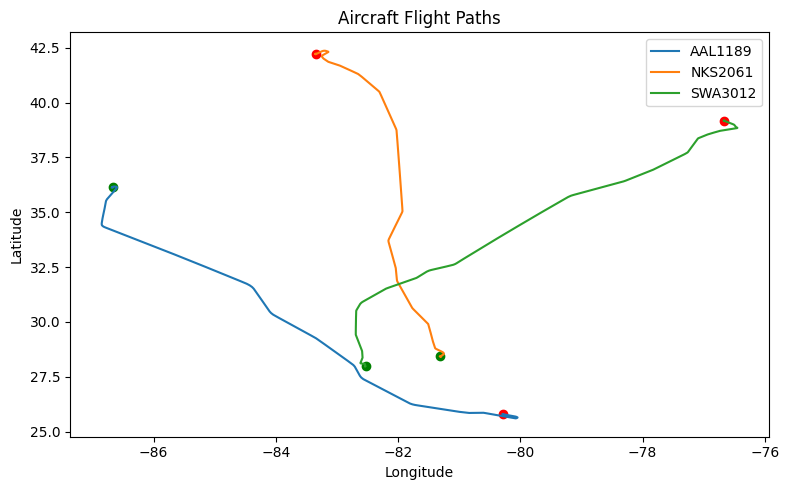

In [43]:
plt.figure(figsize=(8,5))

for callsign, df in aircraft_data.items():

    plt.plot(df["lon"], df["lat"], label=callsign)

    plt.scatter(df["lon"].iloc[0], df["lat"].iloc[0], color="green")
    plt.scatter(df["lon"].iloc[-1], df["lat"].iloc[-1], color="red")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Aircraft Flight Paths")

plt.legend()

plt.tight_layout()

#plt.savefig("flight_paths.png", dpi=150)

plt.show()

In [44]:
COLOURS = ['#00c8e0', '#ff9d00', '#00ff9d', '#ff4488', '#bf55ff']
 
def hex_rgba(hex_color, alpha=1.0):
    h = hex_color.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'
 
# ── BUILD FIGURE ────────────────────────────────────────────────
fig = go.Figure()
 
mid_lat = (df['lat'].max() + df['lat'].min()) / 2
mid_lon = (df['lon'].max() + df['lon'].min()) / 2
 
for idx, (cs, data) in enumerate(aircraft_data.items()):
    colour = COLOURS[idx % len(COLOURS)]
 
    # Faint path line
    fig.add_trace(go.Scattergeo(
        lat=data['lat'], lon=data['lon'],
        mode='lines',
        line=dict(width=1.5, color=hex_rgba(colour, 0.3)),
        hoverinfo='skip',
        showlegend=False,
    ))
 
    # Dots coloured by altitude
    fig.add_trace(go.Scattergeo(
        lat=data['lat'], lon=data['lon'],
        mode='markers',
        marker=dict(
            size=5,
            color=data['Altitude'],
            colorscale=[
                [0.0, '#0a0f2e'],
                [0.3, hex_rgba(colour, 0.6)],
                [0.7, colour],
                [1.0, '#ffffff'],
            ],
            cmin=0, cmax=40000,
            showscale=False,
            opacity=0.9,
        ),
        text=[
            f"<b>{cs}</b><br>"
            f"⏱  {r.UTC.strftime('%H:%M:%S')} UTC<br>"
            f"✈  {int(r.Altitude):,} ft<br>"
            f"💨 {int(r.Speed)} kts<br>"
            f"🧭 {int(r.Direction)}°"
            for _, r in data.iterrows()
        ],
        hoverinfo='text',
        hoverlabel=dict(
            bgcolor='#050c1c', bordercolor=colour,
            font=dict(color='#c8eaf5', size=12, family='Courier New'),
        ),
        name=cs,
        showlegend=True,
    ))
 
    # Departure marker ●
    fig.add_trace(go.Scattergeo(
        lat=[data['lat'].iloc[0]], lon=[data['lon'].iloc[0]],
        mode='markers',
        marker=dict(size=14, color=colour, symbol='circle',
                    line=dict(color='white', width=2)),
        hovertext=f"<b>DEPARTURE — {cs}</b><br>{data['lat'].iloc[0]:.3f}°N  {abs(data['lon'].iloc[0]):.3f}°W",
        hoverinfo='text',
        showlegend=False,
    ))
 
    # Arrival marker ■
    fig.add_trace(go.Scattergeo(
        lat=[data['lat'].iloc[-1]], lon=[data['lon'].iloc[-1]],
        mode='markers',
        marker=dict(size=14, color=colour, symbol='square',
                    line=dict(color='white', width=2)),
        hovertext=f"<b>ARRIVAL — {cs}</b><br>{data['lat'].iloc[-1]:.3f}°N  {abs(data['lon'].iloc[-1]):.3f}°W",
        hoverinfo='text',
        showlegend=False,
    ))
 
# ── MAP STYLE ───────────────────────────────────────────────────
fig.update_geos(
    projection=dict(type='orthographic',
                    rotation=dict(lon=mid_lon, lat=mid_lat)),
    center=dict(lat=mid_lat, lon=mid_lon),
    showland=True,       landcolor='#0d1b2a',
    showocean=True,      oceancolor='#060d1a',
    showlakes=True,      lakecolor='#081422',
    showcountries=True,  countrycolor='rgba(60,100,160,0.5)',  countrywidth=0.6,
    showcoastlines=True, coastlinecolor='rgba(0,140,200,0.7)', coastlinewidth=1,
    showsubunits=True,   subunitcolor='rgba(40,80,130,0.4)',   subunitwidth=0.5,
    lonaxis=dict(range=[df['lon'].min() - 4, df['lon'].max() + 4]),
    lataxis=dict(range=[df['lat'].min() - 4, df['lat'].max() + 4]),
    bgcolor='#030810',
)
 
fig.update_layout(
    title=dict(text='Aircraft Trajectories', font=dict(color='#00c8e0', family='Courier New')),
    paper_bgcolor='#030810',
    legend=dict(
        font=dict(color='#c8eaf5', family='Courier New'),
        bgcolor='rgba(4,12,26,0.8)',
        bordercolor='rgba(0,180,220,0.3)',
        borderwidth=1,
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=800,
)
 
# ── SAVE & OPEN ─────────────────────────────────────────────────
fig.write_html('aircraft_map.html', config={'scrollZoom': True, 'displaylogo': False})
webbrowser.open('file://' + os.path.abspath('aircraft_map.html'))


True